# Quarterly cross-sectional regressions of cumulative CPI inflation on $\xi$

For each quarter, this notebook runs a separate cross-country regression of cumulative CPI inflation on country-level `xi` and lagged controls.

- Default target: cumulative CPI from `t` through `t+3`
- Default controls: lagged CPI, exchange-rate changes, output gap, and policy rate
- Default `u`: the common quarterly oil shock `oil_pct_change`
- Scatter: quarter-specific `xi` coefficient against `u`, with bubble size proportional to `u^2`

If you want `u` to be the Kaenzig quarterly surprise instead, change `u_col = "news"` in the config cell.


In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from io_networks import local_projections as lp


In [8]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
news_path = ROOT / "data/processed/oil/kaenzig_oil_supply_surprises_quarterly.csv"

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    },
]

horizon = 4  # cumulative CPI from t through t+3
sample_start = 1999
sample_end = None

u_col = "oil_pct_change"  # "oil_pct_change" or "news"
restrict_u_to_iqr = False
lag_xi_years = 1
y_lags = 3
control_lags = 3
control_names = ["exchange_rate", "output_gap", "policy_rate"]
min_extra_obs = 2
top_n_labels = 8

print("horizon:", horizon)
print("u_col:", u_col)
print("restrict_u_to_iqr:", restrict_u_to_iqr)
print("lag_xi_years:", lag_xi_years)
print("y_lags:", y_lags)
print("control_lags:", control_lags)


horizon: 4
u_col: oil_pct_change
restrict_u_to_iqr: False
lag_xi_years: 1
y_lags: 3
control_lags: 3


In [9]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    news_path=news_path,
    news_column="news_shock",
    cpi_freq="Q",
    controls=panel_controls,
    sample_start=sample_start,
    sample_end=sample_end,
)
panel_df = lp.build_cumulative_targets(panel_df, horizons=horizon)

work = panel_df.sort_values(["country", "time_index"]).reset_index(drop=True).copy()

if lag_xi_years < 0:
    raise ValueError("lag_xi_years must be >= 0")
work["xi_reg"] = work.groupby("country")["xi"].shift(4 * lag_xi_years) if lag_xi_years > 0 else work["xi"]

y_lag_cols = []
for lag in range(1, y_lags + 1):
    col = f"cpi_pct_change_lag{lag}"
    work[col] = work.groupby("country")["cpi_pct_change"].shift(lag)
    y_lag_cols.append(col)

control_lag_cols = []
for control in control_names:
    for lag in range(1, control_lags + 1):
        col = f"{control}_lag{lag}"
        work[col] = work.groupby("country")[control].shift(lag)
        control_lag_cols.append(col)

dep_col = f"cum_cpi_lead{horizon}"
x_cols = ["xi_reg", *y_lag_cols, *control_lag_cols]

display(work[["country", "period", dep_col, "xi_reg", u_col, *x_cols[1:6]]].head())
print("Rows in quarterly panel:", len(work))
print("Countries:", work["country"].nunique())
print("Quarter range:", work["period"].min(), "to", work["period"].max())


,country,period,cum_cpi_lead4,xi_reg,oil_pct_change,cpi_pct_change_lag1,cpi_pct_change_lag2,cpi_pct_change_lag3,exchange_rate_lag1,exchange_rate_lag2
0,AGO,2002-Q2,0.995316,NaN,0.189848,NaN,NaN,NaN,NaN,NaN
1,AGO,2002-Q3,0.964998,NaN,0.066242,0.171750,NaN,NaN,0.147258,NaN
2,AGO,2002-Q4,0.838549,NaN,-0.011465,0.209522,0.171750,NaN,0.131988,0.147258
3,AGO,2003-Q1,0.757885,NaN,0.162677,0.179419,0.209522,0.171750,0.157769,0.131988
4,AGO,2003-Q2,0.610653,0.085897,-0.167036,0.234092,0.179419,0.209522,0.181845,0.157769


Rows in quarterly panel: 6734
Countries: 80
Quarter range: 1999-Q1 to 2022-Q4


In [10]:
results = []
models = {}

required_nobs = len(x_cols) + min_extra_obs

for period, sub in work.groupby("period", sort=True):
    design = sub[["country", "period", dep_col, u_col, *x_cols]].dropna().reset_index(drop=True)
    if design.empty:
        continue
    if design["country"].nunique() < required_nobs:
        continue

    y = design[dep_col]
    x = sm.add_constant(design[x_cols], has_constant="add")
    model = sm.OLS(y, x, missing="raise").fit(cov_type="HC3")
    models[period] = model

    results.append(
        {
            "period": period,
            "nobs": int(model.nobs),
            "u": float(design[u_col].iloc[0]),
            "u_sq": float(design[u_col].iloc[0] ** 2),
            "xi_coef": float(model.params["xi_reg"]),
            "xi_se": float(model.bse["xi_reg"]),
            "xi_t": float(model.tvalues["xi_reg"]),
            "xi_pvalue": float(model.pvalues["xi_reg"]),
            "r2": float(model.rsquared),
        }
    )

coef_df = pd.DataFrame(results).sort_values("period").reset_index(drop=True)
coef_df["period_dt"] = pd.PeriodIndex(coef_df["period"], freq="Q").to_timestamp("Q")

print("Quarterly regressions estimated:", len(coef_df))
display(coef_df.head(10))


Quarterly regressions estimated: 88


,period,nobs,u,u_sq,xi_coef,xi_se,xi_t,xi_pvalue,r2,period_dt
0,2000-Q1,28,0.117547,1.381726e-02,1.439564,0.901630,1.596624,0.110349,0.819504,2000-03-31
1,2000-Q2,29,-0.000651,4.232789e-07,0.550293,0.690573,0.796865,0.425530,0.793855,2000-06-30
2,2000-Q3,29,0.112015,1.254733e-02,0.391917,0.659436,0.594322,0.552297,0.806578,2000-09-30
3,2000-Q4,29,-0.011140,1.240937e-04,0.171007,0.666873,0.256431,0.797618,0.819051,2000-12-31
4,2001-Q1,29,-0.122910,1.510675e-02,0.333909,0.877275,0.380621,0.703484,0.793978,2001-03-31
5,2001-Q2,29,0.025693,6.601079e-04,0.170822,0.560990,0.304500,0.760747,0.768303,2001-06-30
6,2001-Q3,29,-0.056254,3.164542e-03,0.431764,0.419635,1.028905,0.303524,0.831334,2001-09-30
7,2001-Q4,30,-0.270271,7.304623e-02,1.066348,1.532515,0.695815,0.486544,0.620680,2001-12-31
8,2002-Q1,30,0.077184,5.957416e-03,0.752213,0.698182,1.077388,0.281307,0.808548,2002-03-31
9,2002-Q2,30,0.189848,3.604211e-02,0.218449,0.918715,0.237777,0.812054,0.852924,2002-06-30


Scatter sample uses all estimated quarters.


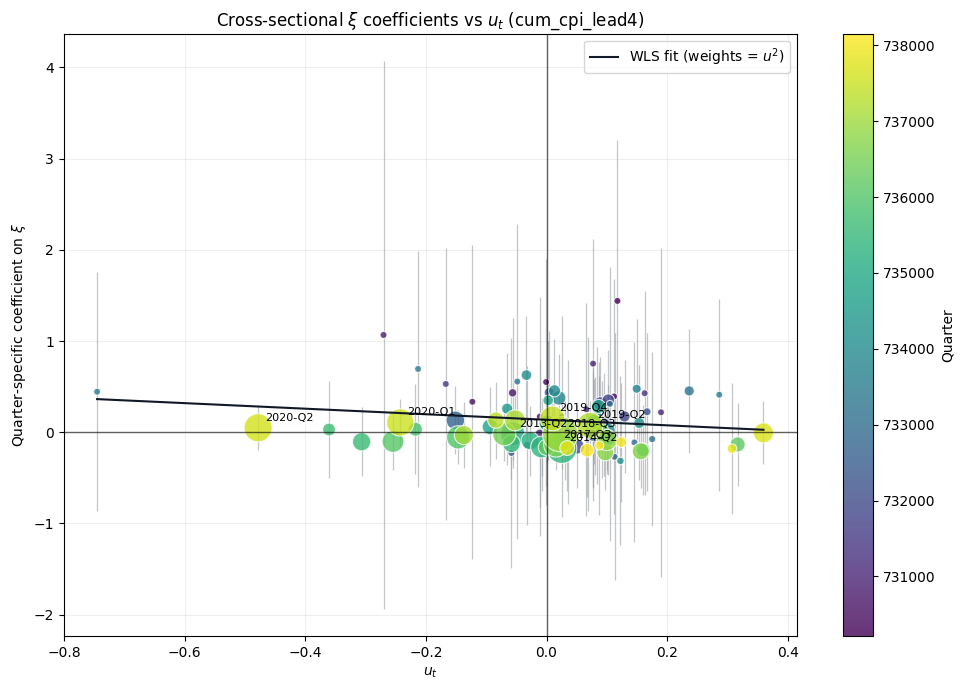

Quarters in scatter sample: 88 out of 88
                            WLS Regression Results                            
Dep. Variable:                xi_coef   R-squared:                       0.150
Model:                            WLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     15.16
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000194
Time:                        01:55:13   Log-Likelihood:                -93.922
No. Observations:                  88   AIC:                             191.8
Df Residuals:                      86   BIC:                             196.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

In [11]:
scatter_df = coef_df.copy()
if restrict_u_to_iqr:
    u_q1 = scatter_df["u"].quantile(0.25)
    u_q3 = scatter_df["u"].quantile(0.75)
    scatter_df = scatter_df.loc[scatter_df["u"].between(u_q1, u_q3)].copy()
    print(f"Restricting scatter sample to IQR of u: [{u_q1:.6f}, {u_q3:.6f}]")
else:
    print("Scatter sample uses all estimated quarters.")

if len(scatter_df) < 3:
    raise ValueError("Not enough quarters left after the u IQR filter. Disable the filter or expand the sample.")

weighted_fit = sm.WLS(
    scatter_df["xi_coef"],
    sm.add_constant(scatter_df[["u"]], has_constant="add"),
    weights=scatter_df["u_sq"].clip(lower=np.finfo(float).eps),
).fit()

scatter_df["xi_var"] = scatter_df["xi_se"] ** 2
scatter_df["weight_inv_var"] = 1.0 / scatter_df["xi_var"].clip(lower=np.finfo(float).eps)

scale_base = scatter_df["weight_inv_var"].median()
if not np.isfinite(scale_base) or scale_base <= 0:
    scale_base = 1.0
marker_sizes = 80.0 * scatter_df["weight_inv_var"] / scale_base
marker_sizes = marker_sizes.clip(lower=25.0, upper=900.0)

fig, ax = plt.subplots(figsize=(10, 7))
ax.errorbar(
    scatter_df["u"],
    scatter_df["xi_coef"],
    yerr=1.96 * scatter_df["xi_se"],
    fmt="none",
    ecolor="#9aa0a6",
    elinewidth=0.9,
    alpha=0.6,
    zorder=1,
)
scatter = ax.scatter(
    scatter_df["u"],
    scatter_df["xi_coef"],
    s=marker_sizes,
    c=scatter_df["period_dt"].map(pd.Timestamp.toordinal),
    cmap="viridis",
    alpha=0.8,
    edgecolor="white",
    linewidth=0.8,
    zorder=2,
)

u_grid = np.linspace(scatter_df["u"].min(), scatter_df["u"].max(), 200)
fit_grid = pd.DataFrame({"const": 1.0, "u": u_grid})
ax.plot(u_grid, weighted_fit.predict(fit_grid), color="#111827", linewidth=1.5, label="WLS fit (weights = $u^2$)")

label_df = scatter_df.nlargest(top_n_labels, "weight_inv_var")
for row in label_df.itertuples(index=False):
    ax.annotate(row.period, (row.u, row.xi_coef), xytext=(5, 5), textcoords="offset points", fontsize=8)

ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
ax.axvline(0.0, color="black", linewidth=1.0, alpha=0.6)
ax.set_xlabel(r"$u_t$")
ax.set_ylabel(r"Quarter-specific coefficient on $\xi$")
ax.set_title(rf"Cross-sectional $\xi$ coefficients vs $u_t$ ({dep_col})")
ax.legend(loc="best")
ax.grid(alpha=0.2)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Quarter")

plt.tight_layout()
plt.show()

print("Quarters in scatter sample:", len(scatter_df), "out of", len(coef_df))
print(weighted_fit.summary())


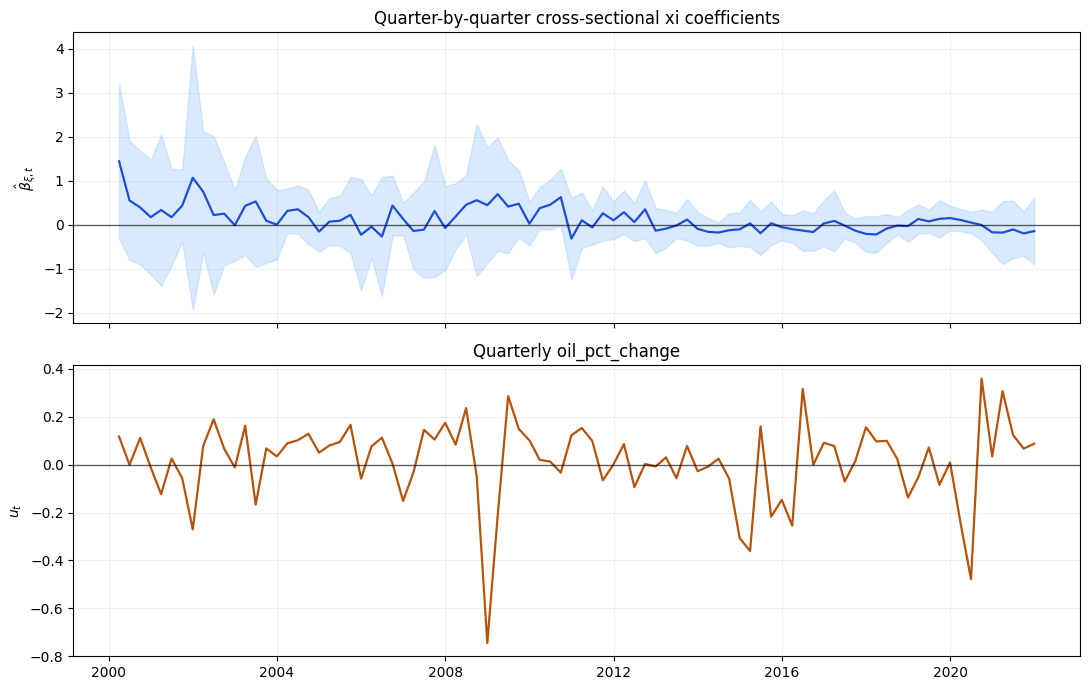

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(coef_df["period_dt"], coef_df["xi_coef"], color="#1d4ed8", linewidth=1.6)
axes[0].fill_between(
    coef_df["period_dt"],
    coef_df["xi_coef"] - 1.96 * coef_df["xi_se"],
    coef_df["xi_coef"] + 1.96 * coef_df["xi_se"],
    color="#93c5fd",
    alpha=0.35,
)
axes[0].axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
axes[0].set_ylabel(r"$\hat\beta_{\xi,t}$")
axes[0].set_title("Quarter-by-quarter cross-sectional xi coefficients")
axes[0].grid(alpha=0.2)

axes[1].plot(coef_df["period_dt"], coef_df["u"], color="#b45309", linewidth=1.6)
axes[1].axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
axes[1].set_ylabel(r"$u_t$")
axes[1].set_title(f"Quarterly {u_col}")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()
